# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: XX     |  |
| :-------------|:-------------|
| Alesja Zorina| 6575129 |
| Jan van de Poll| 6527590 |
| Pepper van Berkum| 6525512 |
| Planning Groep: 23     |We zijn om 15:00 klaar!? wss gewoon 17:30 |
|---|---|
| Testmeting | 11:30 |
| Arduino referentiecondensator testen | 11:40 |
| Condensator maken en testen | 12:30 |
| De capacitatieve sensor geschetst hebben| 13:45 |
| De sensor bouwen | 14:30 |
| Kalibratie plot en aftekenen | 16:00 |
| Pauze 1| 14:30-14:45 |
| Pauze 2| ? |

In [1]:
#Bibliotheken importeren
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

epsilon0 = 8.854187817e-12
R = 1000 #ohm
f = 1e5 #Hz

## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="IMG_6704" alt="schets student 1" width="400"/>

In [2]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!

var = np.array([]) #onze gekozen variabele

def vlakkeplaatlijst(epsilonrel, A, var):
    cap = np.array([]) #de capaciteit die hoort bij de gekozen variabele
    for x in range(len(var)):
        cap = np.append(cap, epsilon0 * epsilonrel * A / var[x]) #de index toevoegen die correspondeert met de var
    return cap

def vlakkeplaat(epsilonrel, A, d):
    return epsilon0 * epsilonrel * A / d

def vlakkeplaatdef(Amp1, Amp2):
    return Amp1/(R*2*np.pi*f*Amp2)



In [3]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = np.array([vlakkeplaat(1.4, 0.096**2 , 0.0001)])/1e-9
print(f"Berekende capaciteit plaatcondensator groep 23 is {C[0]:.3f} nF")

Berekende capaciteit plaatcondensator groep 23 is 1.142 nF


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](IMG_6705.JPEG)
![scope meting 2](IMG_6706.JPEG)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 23| 61,2 pF | 0.325 V| 0,3345 V | 65,4 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_6707.JPEG)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij (groep 23) gaan een sensor maken die het gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_6708.JPEG)

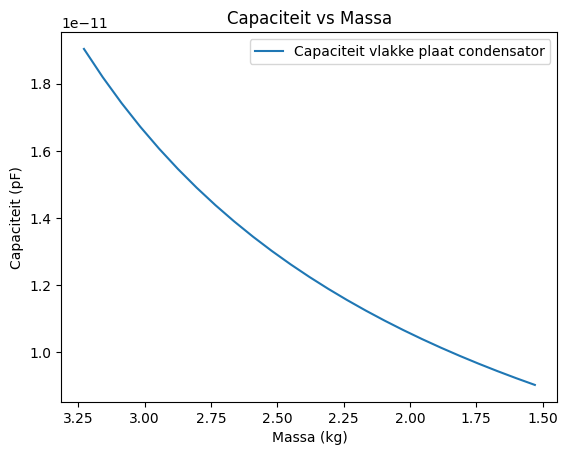

In [4]:
#Wij denken dat de afstand tussen de platen varieert tussen 12,67 mm en 9 mm.
d = np.linspace(0.01267, 0.006, 25)
veerconstante_gok = 2500
masstheo = d*veerconstante_gok/9.81
cap = vlakkeplaatlijst(1.4, 0.096**2 , d)
cap = cap[::-1]


plt.plot(masstheo, cap, label = "Capaciteit vlakke plaat condensator")
plt.gca().invert_xaxis() #omdat de afstand kleiner wordt als de massa groter wordt
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

Ons natuurkundig verband zit het in de afstand tussen de platen die volgt uit de lineare indrukking van een veerkrachtig materiaal; hier de spons. Dus de afstand is recht evenredig met de geplaatste massa op de plaat. Omdat een kleine massa met een lage capaciteit correspondeert is de x-as geinverteerd voor een betere beschrijving van de realiteit.

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (mV)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 32,4 | 324 |
| gemiddelde capaciteit| 90 | 900 |
| maximale capaciteit| 151 | 1510 |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](tudelftLogo.png)
![meting 2](tudelftLogo.png)

## Opdracht 7: Plot de kalibratiegrafiek.

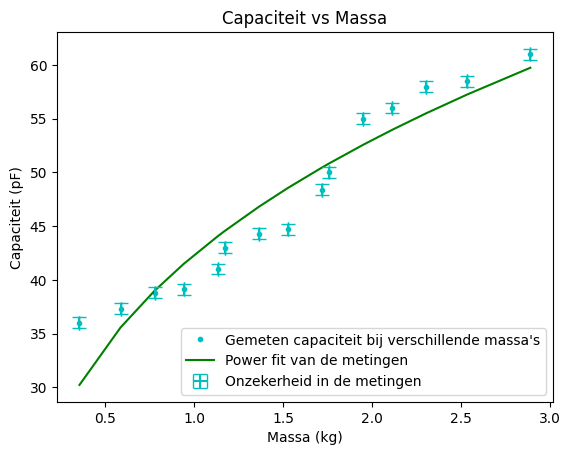

[ 9.12676431  1.16422603 31.97876459]
9.770465698330296e-15


In [5]:
massa = np.array([0.3551, 0.5863, 0.7776, 0.5863+0.3551, 0.7776+0.3551, 1.1717, 0.7776+0.5863, 1.1717+0.3551, 0.7776+0.5863+0.3551, 1.1717+0.5863, 1.1717+0.7776, 1.1717+0.5863+0.3551, 1.1717+0.7776+0.3551, 1.1717+0.7776+0.5863, 1.1717+0.7776+0.5863+0.3551])
cap = np.array([36, 37.3, 38.8, 39.1, 41, 43, 44.3, 44.7, 48.4, 50, 55, 56, 58, 58.5, 61])
capstray = 16

def inverted(x, a, b):
    return a / x + b
popt, pcov = curve_fit(inverted, massa, cap)

def powerfit(x, a, b, c):
    return a * x**b + c
popt_power, pcov_power = curve_fit(powerfit, massa, cap)

plt.plot(massa, cap, "c.", label = "Gemeten capaciteit bij verschillende massa's")
plt.plot(massa, powerfit(massa, *popt_power), "g-", label = "Power fit van de metingen")
plt.errorbar(massa, cap, xerr = 0.0001, yerr=0.5, fmt='none', ecolor='c', capsize=5, label = "Onzekerheid in de metingen")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")  

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

print(popt_power)
print(vlakkeplaat(1, 0.21*0.196, 37.3))

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De spons zijn indrukking is willekeurig bepaald door de luchtbubbeltjes, dus we moeten een veer met een constante veerconstante gebruiken.
* De platen van de condensator steviger maken.

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](IMG_6705.JPEG)

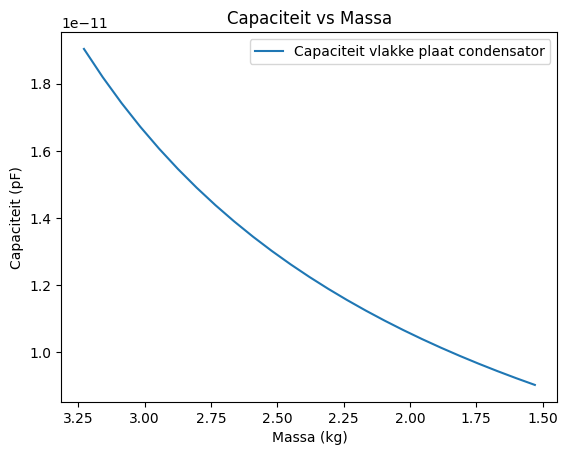

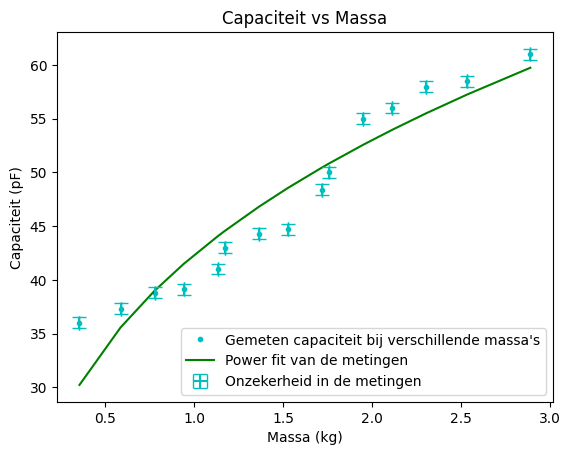

In [6]:
# Ontwerpgrafiek
d = np.linspace(0.01267, 0.006, 25)
veerconstante_gok = 2500
masstheo = d*veerconstante_gok/9.81
cap = vlakkeplaatlijst(1.4, 0.096**2 , d)
cap = cap[::-1]


plt.plot(masstheo, cap, label = "Capaciteit vlakke plaat condensator")
plt.gca().invert_xaxis() #omdat de afstand kleiner wordt als de massa groter wordt
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

# Kalibratiegrafiek oorspronkelijk = uiteindelijk
massa = np.array([0.3551, 0.5863, 0.7776, 0.5863+0.3551, 0.7776+0.3551, 1.1717, 0.7776+0.5863, 1.1717+0.3551, 0.7776+0.5863+0.3551, 1.1717+0.5863, 1.1717+0.7776, 1.1717+0.5863+0.3551, 1.1717+0.7776+0.3551, 1.1717+0.7776+0.5863, 1.1717+0.7776+0.5863+0.3551])
cap = np.array([36, 37.3, 38.8, 39.1, 41, 43, 44.3, 44.7, 48.4, 50, 55, 56, 58, 58.5, 61])
capstray = 16

def powerfit(x, a, b):
    return a * x**b
popt_power, pcov_power = curve_fit(powerfit, massa, cap)

plt.plot(massa, cap, "c.", label = "Gemeten capaciteit bij verschillende massa's")
plt.plot(massa, powerfit(massa, *popt_power), "g-", label = "Power fit van de metingen")
plt.errorbar(massa, cap, xerr = 0.0001, yerr=0.5, fmt='none', ecolor='c', capsize=5, label = "Onzekerheid in de metingen")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")  

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

Ons natuurkundig verband zit het in de afstand tussen de platen die volgt uit de lineare indrukking van een veerkrachtig materiaal; hier de spons. Dus de afstand is recht evenredig met de geplaatste massa op de plaat. Omdat een kleine massa met een lage capaciteit correspondeert is de x-as geinverteerd voor een betere beschrijving van de realiteit.

## Opdracht 10: Vul hieronder de conclusie in.

Het is mogelijk om van een condensator een sensor te maken, echter is het bij ons niet gelukt door beperkingen in de opstelling. De instabiliteit en de spons waren de beperkende factoren. Het natuurkundig verband hoort linear te zijn maar doordat de veerconstante van de spons niet een constante is, geldt dit alleen voor kleine meetwaardes.

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](IMG_6707.JPEG)


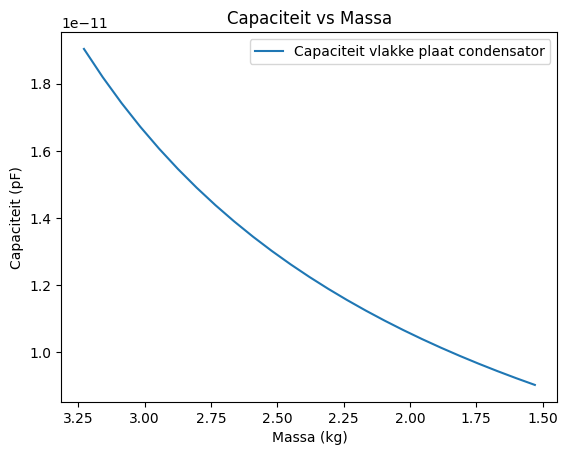

In [7]:
#-------------Kallibratiegrafiek-------------

#Wij denken dat de afstand tussen de platen varieert tussen 12,67 mm en 9 mm.
d = np.linspace(0.01267, 0.006, 25)
veerconstante_gok = 2500
masstheo = d*veerconstante_gok/9.81
cap = vlakkeplaatlijst(1.4, 0.096**2 , d)
cap = cap[::-1]


plt.plot(masstheo, cap, label = "Capaciteit vlakke plaat condensator")
plt.gca().invert_xaxis() #omdat de afstand kleiner wordt als de massa groter wordt
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](IMG_6708.JPEG)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

In [8]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

C = np.array([vlakkeplaat(1.4, 0.096**2 , 0.0001)])/1e-9
print(f"Berekende capaciteit plaatcondensator groep 23 is {C[0]:.3f} nF")

Berekende capaciteit plaatcondensator groep 23 is 1.142 nF



![scope meting 1](IMG_6705.JPEG)
![scope meting 2](IMG_6706.JPEG)

kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

* De spons zijn indrukking is willekeurig bepaald door de luchtbubbeltjes, dus we moeten een veer met een constante veerconstante gebruiken.
* De platen van de condensator steviger maken.

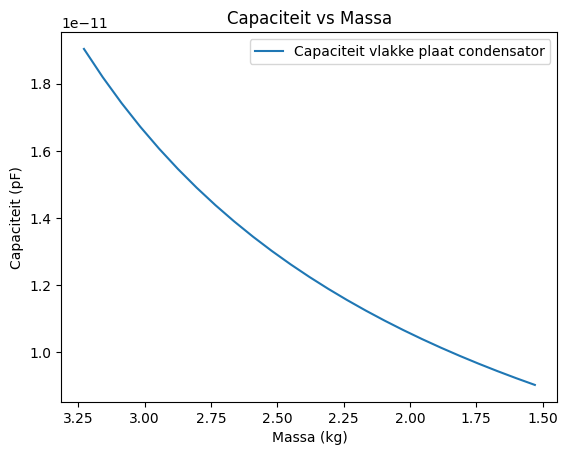

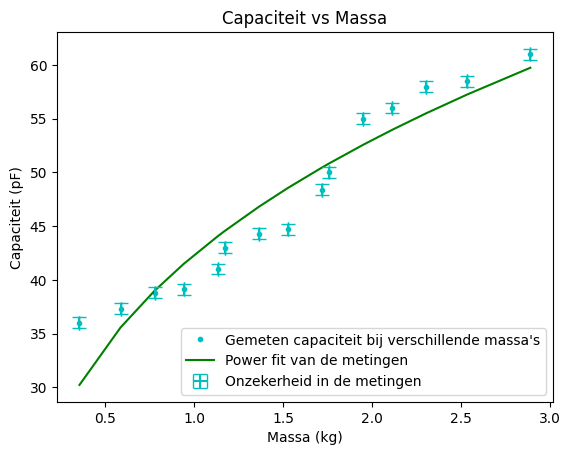

In [9]:
# Ontwerpgrafiek
d = np.linspace(0.01267, 0.006, 25)
veerconstante_gok = 2500
masstheo = d*veerconstante_gok/9.81
cap = vlakkeplaatlijst(1.4, 0.096**2 , d)
cap = cap[::-1]


plt.plot(masstheo, cap, label = "Capaciteit vlakke plaat condensator")
plt.gca().invert_xaxis() #omdat de afstand kleiner wordt als de massa groter wordt
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

# Kalibratiegrafiek oorspronkelijk = uiteindelijk
massa = np.array([0.3551, 0.5863, 0.7776, 0.5863+0.3551, 0.7776+0.3551, 1.1717, 0.7776+0.5863, 1.1717+0.3551, 0.7776+0.5863+0.3551, 1.1717+0.5863, 1.1717+0.7776, 1.1717+0.5863+0.3551, 1.1717+0.7776+0.3551, 1.1717+0.7776+0.5863, 1.1717+0.7776+0.5863+0.3551])
cap = np.array([36, 37.3, 38.8, 39.1, 41, 43, 44.3, 44.7, 48.4, 50, 55, 56, 58, 58.5, 61])
capstray = 16

def powerfit(x, a, b):
    return a * x**b
popt_power, pcov_power = curve_fit(powerfit, massa, cap)

plt.plot(massa, cap, "c.", label = "Gemeten capaciteit bij verschillende massa's")
plt.plot(massa, powerfit(massa, *popt_power), "g-", label = "Power fit van de metingen")
plt.errorbar(massa, cap, xerr = 0.0001, yerr=0.5, fmt='none', ecolor='c', capsize=5, label = "Onzekerheid in de metingen")
plt.xlabel("Massa (kg)")
plt.ylabel("Capaciteit (pF)")  

plt.title("Capaciteit vs Massa")
plt.legend()
plt.show()

Ons natuurkundig verband zit het in de afstand tussen de platen die volgt uit de lineare indrukking van een veerkrachtig materiaal; hier de spons. Dus de afstand is recht evenredig met de geplaatste massa op de plaat. Omdat een kleine massa met een lage capaciteit correspondeert is de x-as geinverteerd voor een betere beschrijving van de realiteit.